In [18]:
import numpy as np
import os
import sklearn.preprocessing
from umap import umap_ as umap
import wavemap_paper
%matplotlib widget
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import pyplot as plt
import random
from wavemap_paper.helper_functions import RAND_STATE, set_rand_state, plot_inverse_mapping
import networkx as nx
import cylouvain
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mplcursors

from cluster import *


# get working directory
os.chdir("d:\\MasterThesis")
os.getcwd()

'd:\\MasterThesis'

In [19]:
# Preprocess
from preprocess import *

fileDirectory_dissorg = "data\\test_data\\"
fileName_dissorg = 'testdata_results.bxr' # name of BXR file 

fileDirectory_excit = "data\\excit_data\\"
fileName_excit = '20240627-iPCS-1806-div35-iNeurons_00.bxr' # name of BXR file 

wf_dissorg = extract_waveforms_from_bxr(fileDirectory_dissorg, fileName_dissorg)
wf_excit = extract_waveforms_from_bxr(fileDirectory_excit, fileName_excit)

wf_dissorg_preprocessed = preprocess_waveforms(
    wf_dissorg,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1},
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_dissorg_SMOOTH.csv")

wf_excit_preprocessed = preprocess_waveforms(
    wf_excit,
    smoothing_method = 'gf',
    smoothing_kwargs={'sigma': 1},
    norm=True,
    export_csv=True,
    export_filename="mean_waveforms_preprocessed_excit_SMOOTH.csv")

Saved 87 mean waveforms to: mean_waveforms_preprocessed_dissorg_SMOOTH.csv
Saved 807 mean waveforms to: mean_waveforms_preprocessed_excit_SMOOTH.csv


### Unsmoothed, unnormalised

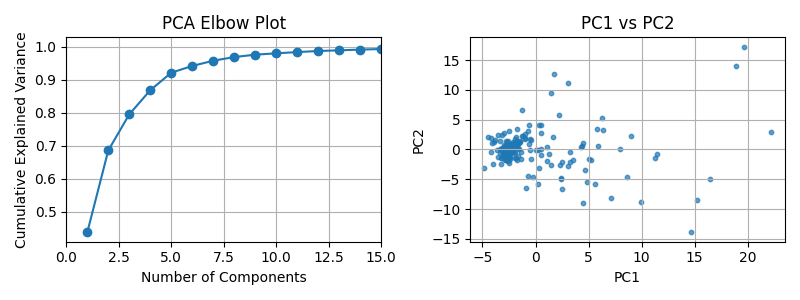

Components that explain 90% of variance: 5


In [20]:
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit_Test.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg_Test.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


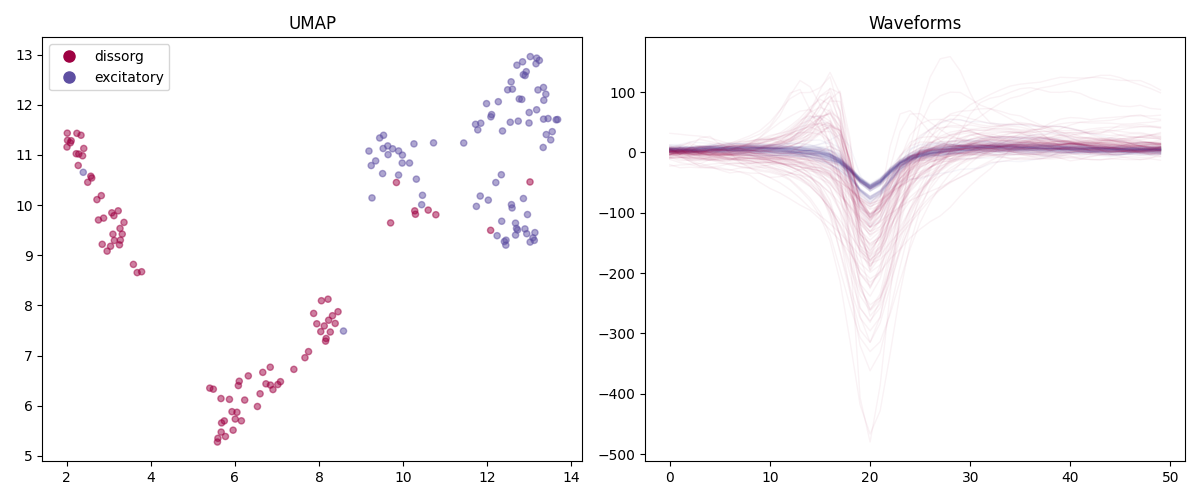

In [13]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")

### Smoothed and Normalised

gf, sigma = 2

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


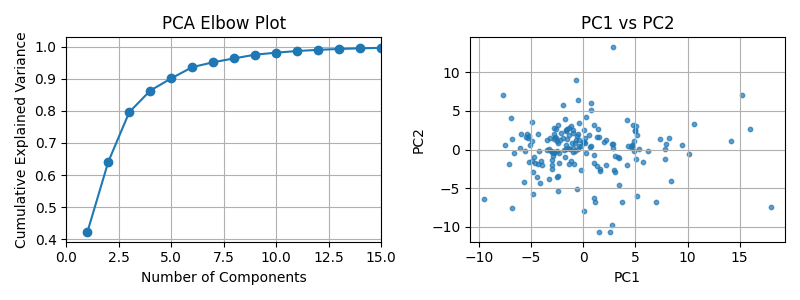

Components that explain 90% of variance: 5


In [21]:
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit_SMOOTH.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg_SMOOTH.csv"

data_list = [data_path_excit, data_path_dissorg]
data_labels = ['excitatory', 'dissorg']

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels)

# Run PCA
X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


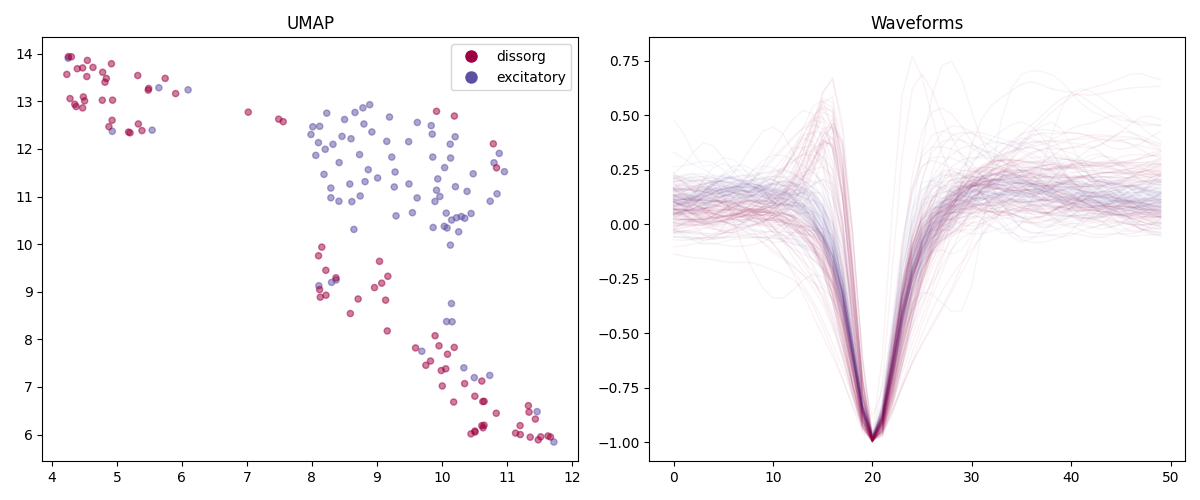

In [22]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=2, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP
interactive_umap_plot(umap_df, cmap_name="Spectral")